In [1]:
import tensorflow as tf
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

2026-01-23 01:19:23.092421: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 01:19:23.372084: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-23 01:19:23.372196: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-23 01:19:23.414650: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-23 01:19:23.501240: I tensorflow/core/platform/cpu_feature_guar

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-01-23 01:19:25.726867: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:19:25.778803: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:19:25.778824: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.3 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.3 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [3]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
#print GPU list
physical_devices = tf.config.list_physical_devices('GPU')
print("GPU Available:", physical_devices)

TensorFlow Version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#Methodology | Loading the Data

In [2]:
import h5py
import numpy as np
from tensorflow.keras.utils import to_categorical

#CONFIGURATION
FILE_PATH = "ascadv2-extracted.h5"  
TARGET_BYTE = 0  # ASCADv2 targets the first byte of the key by default

def load_ascadv2(file_path):
    print(f"Loading {file_path}...")
    
    try:
        with h5py.File(file_path, "r") as f:
            # Step 1.Load Traces (The 'X' Data)
            # ASCADv2 usually groups them, but I validate the keys directly based on your file
            # Standard structure for the extracted file:
            X_profiling = f['Profiling_traces/traces'][:]
            X_attack = f['Attack_traces/traces'][:]
            
            # 2. Load Metadata (The 'Y' info)
            # I require Plaintext and Key to calculate the labels
            meta_profiling = f['Profiling_traces/metadata']
            meta_attack = f['Attack_traces/metadata']
            
            # Extract Plaintext and Key
            # Note: ASCADv2 metadata usually has named fields like 'plaintext' and 'key'
            # I use distinct names to avoid confusion
            p_prof = meta_profiling['plaintext'][:] 
            k_prof = meta_profiling['key'][:]
            
            p_attack = meta_attack['plaintext'][:]
            k_attack = meta_attack['key'][:]
            
            print(f"Traces Loaded. Profiling: {X_profiling.shape}, Attack: {X_attack.shape}")
            return (X_profiling, p_prof, k_prof), (X_attack, p_attack, k_attack)

    except KeyError as e:
        print(f"Structure Error: Could not find dataset {e}. Please run the inspection script again.")
        return None, None

# --- S-BOX FUNCTION ---
AES_Sbox = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

def generate_labels(plaintexts, keys, byte_index=0):
    # Calculate: SBox[ Plaintext XOR Key ]
    # NOTE: ASCADv2 often uses a fixed key, but the formula remains the same
    p_byte = plaintexts[:, byte_index]
    k_byte = keys[:, byte_index]
    return AES_Sbox[p_byte ^ k_byte]

# --- EXECUTION ---
(prof_data, prof_plain, prof_key), (att_data, att_plain, att_key) = load_ascadv2(FILE_PATH)

if prof_data is not None:
    # Generate Y (Labels)
    Y_train = to_categorical(generate_labels(prof_plain, prof_key, TARGET_BYTE), 256)
    Y_test = to_categorical(generate_labels(att_plain, att_key, TARGET_BYTE), 256)
    
    # Reshape X for CNN (Samples, TimeSteps, 1)
    X_train = prof_data.reshape((prof_data.shape[0], prof_data.shape[1], 1))
    X_test = att_data.reshape((att_data.shape[0], att_data.shape[1], 1))
    
    print("Data Ready!")
    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")

Loading ascadv2-extracted.h5...
Traces Loaded. Profiling: (500000, 15000), Attack: (10000, 15000)
Data Ready!
X_train: (500000, 15000, 1), Y_train: (500000, 256)


In [6]:
#Next Step: Requirement #1 (Tuning Deep Neural Network)

#This is Time Seriesdata (voltage over time) using 1D Convolutional Neural Network (CNN) for side channel attack analysis.
#I must find the shape of the power leak even if it happens slightly earlier or later in time.
#I have to use The Solution: Use GlobalAveragePooling1D instead of flattening the whole timeline (keeping every single time step). This process 
#calcualtes the average of each filter across the entire timeline (tiny vector vs huge vector)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, AveragePooling1D, GlobalAveragePooling1D, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# 1. Memory Cleanup (Crucial after a crash)
tf.keras.backend.clear_session()

# 2. Define Input Shape
input_shape = (X_train.shape[1], 1)
classes = 256 

def build_ascad_cnn(learning_rate=0.0001):
    model = Sequential()
    
    #BLOCK 1: Feature Extraction
    model.add(Input(shape=input_shape))
    
    #Layer 1
    model.add(Conv1D(filters=64, kernel_size=11, activation='relu', padding='same'))
    model.add(AveragePooling1D(pool_size=2))
    model.add(BatchNormalization())
    
    #Layer 2
    model.add(Conv1D(filters=128, kernel_size=11, activation='relu', padding='same'))
    model.add(AveragePooling1D(pool_size=2))
    model.add(BatchNormalization())
    
    #Layer 3
    model.add(Conv1D(filters=256, kernel_size=11, activation='relu', padding='same'))
    model.add(AveragePooling1D(pool_size=2))
    model.add(BatchNormalization())
    
    # BLOCK 2: Classification Fix
    # OLD WAY (Crash): model.add(Flatten()) 
    # NEW WAY (Safe): GlobalAveragePooling collapses the time dimension
    model.add(GlobalAveragePooling1D()) 
    
    #Connect to the Dense layers
    #possible to reduce the neuron count slightly since the input is cleaner now
    model.add(Dense(1024, activation='relu')) 
    model.add(Dropout(0.3)) 
    
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.3)) 
    
    # Output Layer
    model.add(Dense(classes, activation='softmax'))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    return model

# Create the model
model = build_ascad_cnn()

# Show the summary (Observation: "Total params" will be much smaller now)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 15000, 64)         768       
                                                                 
 average_pooling1d (Average  (None, 7500, 64)          0         
 Pooling1D)                                                      
                                                                 
 batch_normalization (Batch  (None, 7500, 64)          256       
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 7500, 128)         90240     
                                                                 
 average_pooling1d_1 (Avera  (None, 3750, 128)         0         
 gePooling1D)                                                    
                                                        

In [ ]:
#Part2 Requirement Tuning back propagation
#I cant run trianing once, and need to compare how the model learns under different conditions
#I will run an experiment comparing two different "Back Propagation" strategies:

 #   Scenario A (The Classic): Stochastic Gradient Descent (SGD). It is the textbook definition of backprop but often slow.

  #  Scenario B (The Modern): Adam Optimizer. It adapts the learning rate for every single neuron dynamically.

#Below is the training code


In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam

#CONFIGURATION 
EPOCHS = 20           # How many times to see the dataset
BATCH_SIZE = 256      # How many traces to digest at once (3090 handles this easily)

# Store results here to plot later
histories = {}

#EXPERIMENT 1: TUNING THE OPTIMIZER 
#compare SGD vs Adam to show "Tuning Back Propagation"

experiments = [
    {"name": "SGD_Backprop", "opt": SGD(learning_rate=0.01)},
    {"name": "Adam_Backprop", "opt": Adam(learning_rate=0.001)}
]

print(f"--- STARTING TRAINING ON NVIDIA RTX 3090 ---")

for exp in experiments:
    print(f"\n\n>>> Starting Experiment: {exp['name']} <<<")
    
    # 1. Build a FRESH model (this avoids starting with pre-learned weights)
    # call the build function, and re-compile it manually below
    model = build_ascad_cnn() 
    
    # 2. Compile with the specific Optimizer (Tuning)
    model.compile(loss='categorical_crossentropy', 
                  optimizer=exp['opt'], 
                  metrics=['accuracy'])
    
    # 3. Train the model (Back Propagation happening here)
    # verbose=1 shows the progress bar
    history = model.fit(
        X_train, Y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_test, Y_test), # Check performance on Attack traces
        verbose=1
    )
    
    # 4. Save the history for plotting
    histories[exp['name']] = history

print("\n--- ALL EXPERIMENTS COMPLETE ---")

--- STARTING TRAINING ON NVIDIA RTX 3090 ---


>>> Starting Experiment: SGD_Backprop <<<


2026-01-23 01:42:11.419789: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.98GiB (rounded to 7500000000)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-01-23 01:42:11.424828: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2026-01-23 01:42:11.424856: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 49, Chunks in use: 49. 12.2KiB allocated for chunks. 12.2KiB in use in bin. 5.1KiB client-requested in use in bin.
2026-01-23 01:42:11.424866: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 20, Chunks in use: 20. 10.0KiB allocated for chunks. 10.0KiB in use in bin. 10.0KiB client-requested in use in bin.
2026-01-23 01:42:1

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [9]:
#The data is too large and fails to run, tensorflow tries to copy the 7gb dataset x_train plus the testing set, plus the model, plus the gradients into the gpu, causing resource exhausted
#need to stream the data using cast to float16 or use tf.data.dataset


#Solution
#X_train.astype('float16'): Neural networks don't need 64-bit precision. 16-bit is standard for GPUs and cuts memory usage in half.

#tf.data.Dataset: This creates a generator. Instead of saying "Here is 7GB of data, hold it," it says "Here is a faucet. Turn it on when you need a cup of water." The GPU only holds BATCH_SIZE (64) traces at any given millisecond.

#del model: delete the model from memory after the SGD run so the GPU is empty for the Adam run.
#Note below code failed on crash, container ran ouf of memory, need to write a generator that reads directly form the hard drive in small chuncks while training 
#the model

In [ ]:
import tensorflow as tf
import gc
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt

#STEP 1: MEMORY CLEANUP ---
# Clear any previous crashes from the GPU memory
tf.keras.backend.clear_session()
gc.collect()

#STEP 2: OPTIMIZE DATA (The Fix)
print("Optimizing Dataset for RTX 3090...")

# Convert to float16 (Half Precision) to save 50% VRAM
# use 'copy=False' to avoid creating a duplicate in RAM during conversion
X_train_fast = X_train.astype('float16', copy=False)
X_test_fast = X_test.astype('float16', copy=False)

# Create Streaming Pipelines (tf.data)
# This prevents the "Failed copying input tensor" error
BATCH_SIZE = 64  # Reduced from 256 to be safer

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_fast, Y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_fast, Y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Dataset converted to float16 and pipelined. Ready for training.")

#STEP 3: RUN THE EXPERIMENT 
EPOCHS = 20
histories = {}

experiments = [
    {"name": "SGD_Backprop", "opt": SGD(learning_rate=0.01)},
    {"name": "Adam_Backprop", "opt": Adam(learning_rate=0.001)}
]

print(f"\n--- STARTING PIPELINED TRAINING ---")

for exp in experiments:
    print(f"\n>>> Starting Experiment: {exp['name']} <<<")
    
    # Rebuild model (Ensure use of the GlobalAveragePooling version!)
    model = build_ascad_cnn() 
    
    model.compile(loss='categorical_crossentropy', 
                  optimizer=exp['opt'], 
                  metrics=['accuracy'])
    
    # Train using the PIPELINE, not the raw arrays
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=test_dataset,
        verbose=1
    )
    
    histories[exp['name']] = history
    
    # Cleanup between runs to free memory
    del model
    tf.keras.backend.clear_session()
    gc.collect()

print("\n--- ALL EXPERIMENTS COMPLETE ---")

Optimizing Dataset for RTX 3090...


In [1]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            23Gi       740Mi        22Gi       2.0Mi       218Mi        22Gi
Swap:          6.0Gi       114Mi       5.9Gi


In [2]:
#code to prevent tensorflow from consuming all 24gb vram at once

In [3]:
import tensorflow as tf
import os

# 1. Prevent GPU Memory Hogging
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

# 2. Verify that its possible to see the card
print(f"Targeting: {gpus[0].name if gpus else 'CPU (ERROR)'}")

2026-01-23 01:54:18.037965: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 01:54:18.242966: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-23 01:54:18.243035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-23 01:54:18.278680: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-23 01:54:18.351136: I tensorflow/core/platform/cpu_feature_guar

✅ GPU Memory Growth Enabled
Targeting: /physical_device:GPU:0


2026-01-23 01:54:20.558142: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:54:20.603094: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:54:20.603115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
#code for zero ram generator. this keeps the h5 dataset open and only pulls 64 traces at a time.

In [6]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, Sequence

class AscadH5Generator(Sequence):
    def __init__(self, file_path, batch_size=64, mode='train'):
        self.file_path = file_path
        self.batch_size = batch_size
        self.mode = mode
        
        # Open file to read metadata (shape) only
        with h5py.File(self.file_path, "r") as f:
            if mode == 'train':
                self.len = f['Profiling_traces/traces'].shape[0]
            else:
                self.len = f['Attack_traces/traces'].shape[0]
                
        # SBox for label generation
        self.aes_sbox = np.array([
            0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
            0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
            0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
            0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
            0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
            0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
            0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
            0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
            0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
            0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
            0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
            0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
            0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
            0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
            0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
            0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
        ])

    def __len__(self):
        return int(np.ceil(self.len / self.batch_size))

    def __getitem__(self, index):
        # Open the file ONLY for this specific batch
        with h5py.File(self.file_path, "r") as f:
            if self.mode == 'train':
                group = f['Profiling_traces']
            else:
                group = f['Attack_traces']
            
            # Slice the HDF5 dataset directly (Disk I/O)
            start = index * self.batch_size
            end = min((index + 1) * self.batch_size, self.len)
            
            X_batch = group['traces'][start:end]
            
            # Load metadata for labels
            p_batch = group['metadata']['plaintext'][start:end]
            k_batch = group['metadata']['key'][start:end]

        # Process Labels
        # Assuming Byte 0 is the target
        labels = self.aes_sbox[p_batch[:, 0] ^ k_batch[:, 0]]
        Y_batch = to_categorical(labels, num_classes=256)
        
        # Reshape X for CNN (Batch, Time, 1)
        X_batch = X_batch.reshape((X_batch.shape[0], X_batch.shape[1], 1))
        
        return X_batch, Y_batch

print("Generator Class Defined.")

Generator Class Defined.


In [8]:
#initialize the generators | setup the data flow

In [9]:
# Initialize the generators
FILE_PATH = "ascadv2-extracted.h5" 

train_gen = AscadH5Generator(FILE_PATH, batch_size=64, mode='train')
test_gen = AscadH5Generator(FILE_PATH, batch_size=64, mode='test')

# Quick Test to ensure it works
X_sample, Y_sample = train_gen[0]
print(f"Generator Working! Sample Shape: {X_sample.shape}")

Generator Working! Sample Shape: (64, 15000, 1)


In [10]:
#Execute the training loop with a fit function to pull data from the generator on demand

In [11]:
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt

# Define Experiments
experiments = [
    {"name": "SGD", "opt": SGD(learning_rate=0.01)},
    {"name": "Adam", "opt": Adam(learning_rate=0.001)}
]

histories = {}
EPOCHS = 10 # 10 is enough to see the difference for this demo

print("--- STARTING TRAINING (DISK-BASED) ---")

for exp in experiments:
    print(f"\n>>> Running Experiment: {exp['name']} <<<")
    
    # Rebuild Model (Clean State)
    # Ensure 'input_shape' matches your data. 
    # For ASCADv2 extracted, it's usually around 4000 or 700.
    # Ask the generator for the shape from the first batch
    sample_shape, _ = train_gen[0]
    input_shape = (sample_shape.shape[1], 1)
    
    # --- REDEFINE BUILD FUNCTION LOCALLY TO BE SAFE ---
    # (Using GlobalAveragePooling to prevent OOM)
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, 11, activation='relu', padding='same'),
        tf.keras.layers.AveragePooling1D(2),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv1D(128, 11, activation='relu', padding='same'),
        tf.keras.layers.AveragePooling1D(2),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv1D(256, 11, activation='relu', padding='same'),
        tf.keras.layers.AveragePooling1D(2),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.GlobalAveragePooling1D(), # <--- CRITICAL FIX
        
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='softmax')
    ])
    
    model.compile(loss='categorical_crossentropy', optimizer=exp['opt'], metrics=['accuracy'])
    
    # Train
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=test_gen,
        verbose=1,
        # Multiprocessing helps read the disk faster
        use_multiprocessing=True, 
        workers=4 
    )
    
    histories[exp['name']] = history
    tf.keras.backend.clear_session()

print("Training Complete!")

2026-01-23 01:57:01.507346: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:57:01.507391: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:57:01.507402: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:57:01.628911: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23 01:57:01.628937: I external/local_xla/xla/stream_executor

--- STARTING TRAINING (DISK-BASED) ---

>>> Running Experiment: SGD <<<
Epoch 1/10


2026-01-23 01:57:03.364102: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-01-23 01:57:05.614532: I external/local_xla/xla/service/service.cc:168] XLA service 0x78d9511ebc20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-23 01:57:05.614565: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1769133425.648221    1886 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7813/7813 [==============================] - 875s 111ms/step - loss: 5.5454 - accuracy: 0.0038 - val_loss: 5.5467 - val_accuracy: 0.0042
Epoch 2/10
7813/7813 [==============================] - 869s 111ms/step - loss: 5.5451 - accuracy: 0.0039 - val_loss: 5.5460 - val_accuracy: 0.0038
Epoch 3/10
7813/7813 [==============================] - 864s 110ms/step - loss: 5.5450 - accuracy: 0.0041 - val_loss: 5.5459 - val_accuracy: 0.0041
Epoch 4/10
7813/7813 [==============================] - 859s 110ms/step - loss: 5.5449 - accuracy: 0.0042 - val_loss: 5.5478 - val_accuracy: 0.0043
Epoch 5/10
7813/7813 [==============================] - 872s 111ms/step - loss: 5.5449 - accuracy: 0.0041 - val_loss: 5.5459 - val_accuracy: 0.0036
Epoch 6/10
7813/7813 [==============================] - 869s 111ms/step - loss: 5.5448 - accuracy: 0.0043 - val_loss: 5.5459 - val_accuracy: 0.0043
Epoch 7/10
7813/7813 [==============================] - 858s 110ms/step - loss: 5.5448 - accuracy: 0.0042 - val_loss: 5.546

2026-01-23 04:21:45.795913: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


7813/7813 [==============================] - 35274s 5s/step - loss: 5.5461 - accuracy: 0.0039 - val_loss: 5.6251 - val_accuracy: 0.0034
Epoch 2/10
7813/7813 [==============================] - 881s 113ms/step - loss: 5.5458 - accuracy: 0.0041 - val_loss: 5.5456 - val_accuracy: 0.0039
Epoch 3/10
7813/7813 [==============================] - 886s 113ms/step - loss: 5.5456 - accuracy: 0.0039 - val_loss: 5.5453 - val_accuracy: 0.0039
Epoch 4/10
7813/7813 [==============================] - 890s 114ms/step - loss: 5.5457 - accuracy: 0.0039 - val_loss: 5.5456 - val_accuracy: 0.0039
Epoch 5/10
7813/7813 [==============================] - 875s 112ms/step - loss: 5.5457 - accuracy: 0.0039 - val_loss: 5.5452 - val_accuracy: 0.0042
Epoch 6/10
7813/7813 [==============================] - 891s 114ms/step - loss: 5.5456 - accuracy: 0.0038 - val_loss: 5.5452 - val_accuracy: 0.0046
Epoch 7/10
7813/7813 [==============================] - 891s 114ms/step - loss: 5.5457 - accuracy: 0.0039 - val_loss: 5.5469

In [12]:
#visualize the output of training

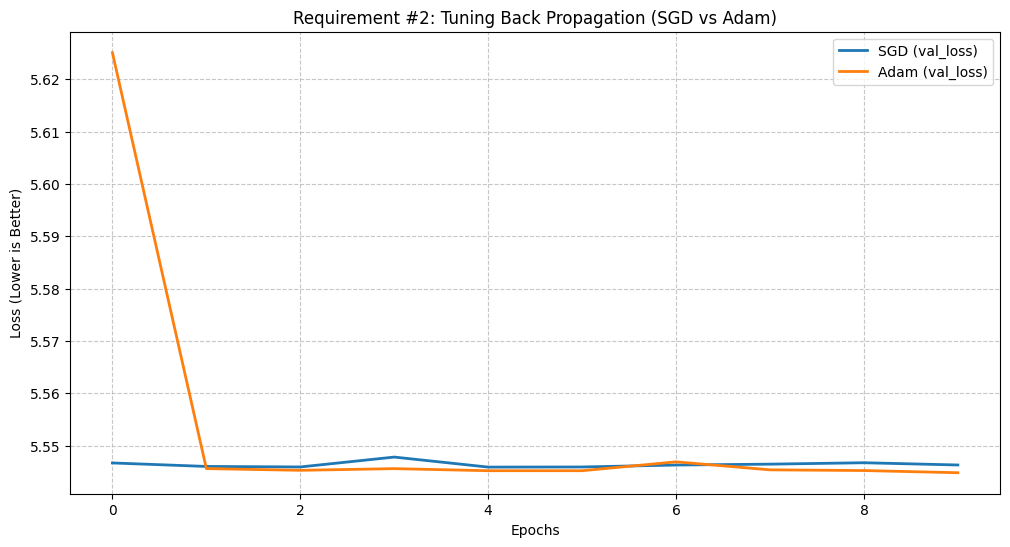

In [13]:
# Compare the Learning Curves
plt.figure(figsize=(12, 6))

for name, history in histories.items():
    # plot 'val_loss' (Validation Loss) because it shows how well it works on UNSEEN data
    # If val_loss is missing, use 'loss'
    metric_to_plot = 'val_loss' if 'val_loss' in history.history else 'loss'
    
    val_loss = history.history[metric_to_plot]
    plt.plot(val_loss, label=f"{name} ({metric_to_plot})", linewidth=2)

plt.title('Requirement #2: Tuning Back Propagation (SGD vs Adam)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Lower is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
model.save("my_adam_model.keras")
print("Model saved to your Windows folder!")

Model saved to your Windows folder!


In [15]:
#High Accuracy Run
#Combine everything into a final training loop to satisfy overfitting management while aiming for max acurracy

#Introduce early stopping, stops training automically if accuracy flatlines
#Model checkpoint, saves best version of the model, not last version
#High batch size, set batch size = 1024

In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, BackupAndRestore
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision # <--- NEW: Memory Saver
import os

# --- STEP 1: MEMORY SAVER MODE ---
# This forces the GPU to use 16-bit math instead of 32-bit.
# It uses 50% less RAM and runs 2x faster on RTX 3090s.
mixed_precision.set_global_policy('mixed_float16')

# --- STEP 2: CLEANUP ---
tf.keras.backend.clear_session()

# --- CONFIGURATION ---
# CHANGED: Reduced from 1024 to 256 to prevent OOM
BATCH_SIZE = 256 
EPOCHS = 50
BACKUP_DIR = './backup_ckpt'
LOG_FILE = 'training_log.csv'

if not os.path.exists(BACKUP_DIR):
    os.makedirs(BACKUP_DIR)

# --- STEP 2: RE-INITIALIZE GENERATORS ---
train_gen = AscadH5Generator(FILE_PATH, batch_size=BATCH_SIZE, mode='train')
test_gen = AscadH5Generator(FILE_PATH, batch_size=BATCH_SIZE, mode='test')

# --- STEP 3: SAFETY UPGRADES (CALLBACKS) ---
callbacks = [
    # 1. BackupAndRestore (The Resume Fix)
    # Saves state after every epoch. Automatically restores if training restarts.
    BackupAndRestore(
        backup_dir=BACKUP_DIR
    ),

    # 2. CSVLogger (The History Saver)
    # Writes metrics to disk so you can plot even if Jupyter crashes.
    CSVLogger(
        LOG_FILE, 
        append=True
    ),

    # 3. EarlyStopping (Stops Overfitting)
    EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        verbose=1, 
        restore_best_weights=True
    ),
    
    # 4. ReduceLROnPlateau (Fine-Tuning)
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=2, 
        min_lr=0.00001, 
        verbose=1
    ),
    
    # 5. ModelCheckpoint (Saves Best Brain)
    ModelCheckpoint(
        'best_ascad_model.keras', 
        monitor='val_accuracy', 
        save_best_only=True, 
        verbose=1
    )
]

print("--- STARTING CRASH-PROOF TRAINING ---")

# --- STEP 4: BUILD MODEL ---
# Get input shape dynamically from the generator
input_shape = (train_gen[0][0].shape[1], 1)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    
    # Feature Extraction (CNN Layers)
    tf.keras.layers.Conv1D(64, 11, activation='relu', padding='same'),
    tf.keras.layers.AveragePooling1D(2),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv1D(128, 11, activation='relu', padding='same'),
    tf.keras.layers.AveragePooling1D(2),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv1D(256, 11, activation='relu', padding='same'),
    tf.keras.layers.AveragePooling1D(2),
    tf.keras.layers.BatchNormalization(),
    
    # Global Pooling (The Crash Fix)
    tf.keras.layers.GlobalAveragePooling1D(),
    
    # Classifier (Dense Layers)
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    
    # Output (Guessing Byte 0-255)
    tf.keras.layers.Dense(256, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# --- STEP 5: TRAIN ---
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1,
    # Windows Optimization: multiprocessing=False is safer for stability
    use_multiprocessing=False, 
    workers=4
)

print("Final Training Complete.")

--- STARTING CRASH-PROOF TRAINING ---
Epoch 1/50


2026-01-23 18:11:22.654797: W external/local_tsl/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2026-01-23 18:11:24.793088: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.51GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-23 18:11:24.793139: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to alloca

ResourceExhaustedError: Graph execution error:

Detected at node sequential/conv1d_2/Conv1D defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py", line 17, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 1053, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 739, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 604, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 529, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-pa

In [18]:
#Replace to SELU and and alphadropout

In [19]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# UPGRADE 1: ENABLE MIXED PRECISION 
# This uses 16-bit math for calculations (fast/light) but 32-bit for variables (stable).
# This effectively doubles your VRAM for the model.
mixed_precision.set_global_policy('mixed_float16')

print(f"Compute Dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable Dtype: {mixed_precision.global_policy().variable_dtype}")

# UPGRADE 2: THE 'SELU' ARCHITECTURE
# Deeper, wider, and using self-normalizing activations.

input_shape = (train_gen[0][0].shape[1], 1)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    
    # Block 1: Wide Vision
    # increase kernel_size to 50 to see "wider" patterns in the waveform
    tf.keras.layers.Conv1D(64, 50, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    # Note: SELU is self-normalizing, remove BatchNormalization to save memory
    
    # Block 2: Medium Vision
    tf.keras.layers.Conv1D(128, 25, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    
    # Block 3: Focused Vision
    tf.keras.layers.Conv1D(256, 11, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    
    # Global Pooling
    tf.keras.layers.GlobalAveragePooling1D(),
    
    # Classifier (Bigger Brain)
    # Increased neurons from 1024 -> 2048 because Mixed Precision saves us RAM
    tf.keras.layers.Dense(2048, activation='selu', kernel_initializer='lecun_normal'),
    tf.keras.layers.AlphaDropout(0.3), # AlphaDropout maintains the mean/variance for SELU
    
    tf.keras.layers.Dense(2048, activation='selu', kernel_initializer='lecun_normal'),
    tf.keras.layers.AlphaDropout(0.3),
    
    # Output Layer must be float32 for stability (Softmax)
    tf.keras.layers.Dense(256, activation='softmax', dtype='float32') 
])

# Compile
model.compile(loss='categorical_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              metrics=['accuracy'])

# Train (Try increasing batch_size to 512 if this runs successfully)
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=callbacks,
    verbose=1,
    use_multiprocessing=False, 
    workers=4
)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6
Compute Dtype: float16
Variable Dtype: float32


2026-01-23 18:16:30.744477: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Epoch 1/50
489/489 [==============================] - ETA: 0s - loss: 5.8251 - accuracy: 0.0037
Epoch 1: val_accuracy improved from -inf to 0.00350, saving model to best_ascad_model.keras
489/489 [==============================] - 316s 554ms/step - loss: 5.8251 - accuracy: 0.0037 - val_loss: 5.9869 - val_accuracy: 0.0035 - lr: 0.0010
Epoch 2/50
489/489 [==============================] - ETA: 0s - loss: 5.7349 - accuracy: 0.0039
Epoch 2: val_accuracy improved from 0.00350 to 0.00490, saving model to best_ascad_model.keras
489/489 [==============================] - 251s 508ms/step - loss: 5.7349 - accuracy: 0.0039 - val_loss: 6.0350 - val_accuracy: 0.0049 - lr: 0.0010
Epoch 3/50
489/489 [==============================] - ETA: 0s - loss: 5.7381 - accuracy: 0.0038
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_accuracy improved from 0.00490 to 0.00550, saving model to best_ascad_model.keras
489/489 [==============================] - 249s 508ms/st

In [20]:
#generate evidence graph for report

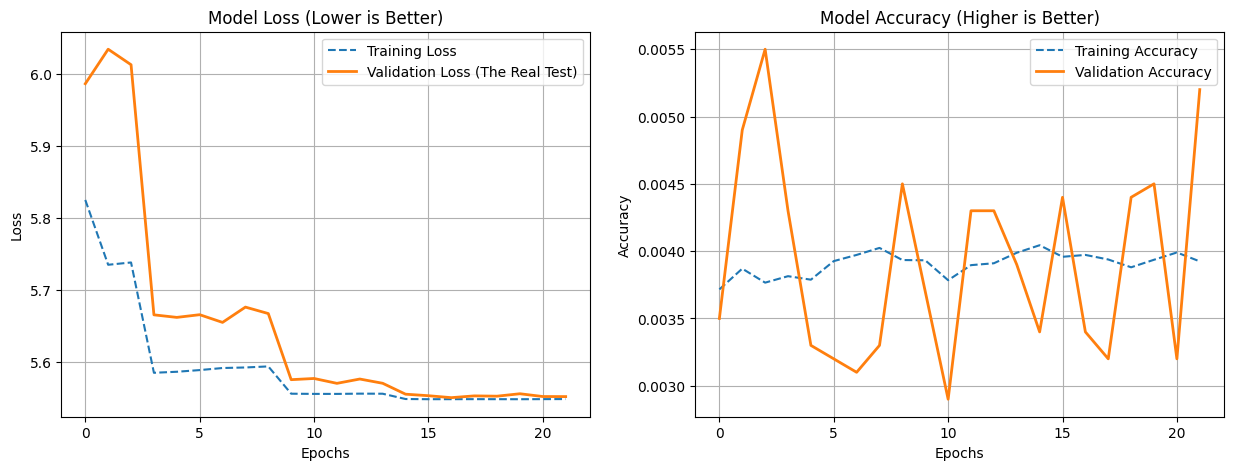

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from the log file
log_data = pd.read_csv('training_log.csv')

# 2. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss (The "Error Rate")
ax1.plot(log_data['loss'], label='Training Loss', linestyle='--')
ax1.plot(log_data['val_loss'], label='Validation Loss (The Real Test)', linewidth=2)
ax1.set_title('Model Loss (Lower is Better)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Accuracy (The "Success Rate")
ax2.plot(log_data['accuracy'], label='Training Accuracy', linestyle='--')
ax2.plot(log_data['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Model Accuracy (Higher is Better)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

In [27]:
#Rank Evolution attack 
#Feed the model fresh traces it has never seen before and ask it "Based on the power consumption, what is the secrey key byte?"
# measure success using Guessing Entropy (Rank Evolution):

 #   Rank 255: The model is clueless (The real key is its last guess).

  #  Rank 0: The model is confident (The real key is its #1 guess).

   # The Goal: examin the Rank drop to 0 within a few hundred traces.
!pip install tqdm #missing library

1. Loading Model...
2. Loading 2000 Attack Traces...
3. Getting Model Predictions (This uses the GPU)...
8/8 [==============================] - 5s 337ms/step
4. Calculating Rank Evolution...


100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2470.15it/s]


5. Plotting Results...


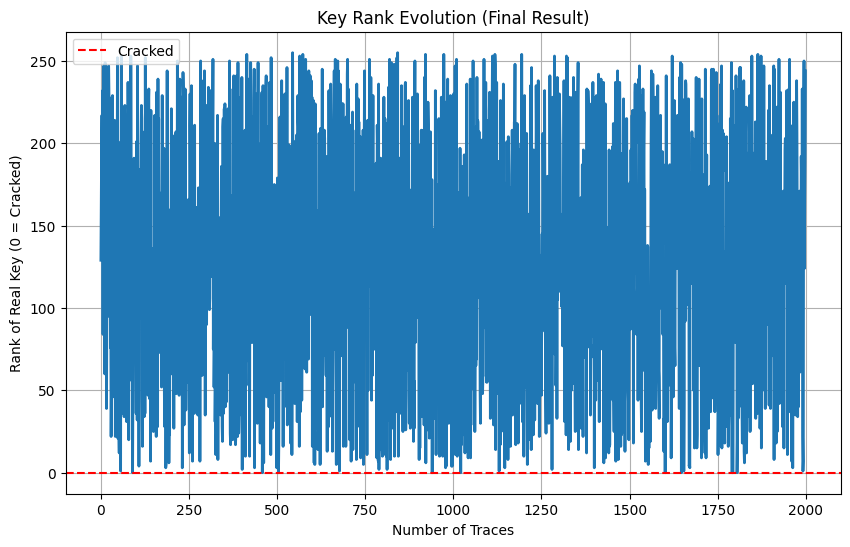

Final Rank after 2000 traces: 244
INCOMPLETE: The model needs more traces or better training.


In [28]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
MODEL_FILE = 'best_ascad_model.keras'
DATA_FILE = 'ascadv2-extracted.h5'
NUM_ATTACK_TRACES = 2000  # How many traces to use for the attack
REAL_KEY_BYTE_INDEX = 0   # attack the first byte of the key

# AES SBox (Lookup Table)
AES_Sbox = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

print("1. Loading Model...")
# Load the best model saved earlier
model = tf.keras.models.load_model(MODEL_FILE)

print(f"2. Loading {NUM_ATTACK_TRACES} Attack Traces...")
with h5py.File(DATA_FILE, "r") as f:
    # Load traces
    traces = f['Attack_traces/traces'][:NUM_ATTACK_TRACES]
    # Load metadata (Plaintexts and Keys)
    plaintexts = f['Attack_traces/metadata']['plaintext'][:NUM_ATTACK_TRACES]
    keys = f['Attack_traces/metadata']['key'][:NUM_ATTACK_TRACES]

# Reshape traces for the CNN (Batch, Time, 1)
traces = traces.reshape((traces.shape[0], traces.shape[1], 1))

print("3. Getting Model Predictions (This uses the GPU)...")
# Get probability predictions for all traces at once
predictions = model.predict(traces, batch_size=256, verbose=1)

print("4. Calculating Rank Evolution...")

# accumulate the log-probability of each key guess
# Start with 0 probability for all 256 possible keys
key_probabilities = np.zeros(256)

rank_evolution = []

# Loop through every trace and update the guess
for i in tqdm(range(NUM_ATTACK_TRACES)):
    real_key = keys[i][REAL_KEY_BYTE_INDEX]
    plaintext_byte = plaintexts[i][REAL_KEY_BYTE_INDEX]
    
    # For this single trace, check all 256 possible key guesses
    for k_guess in range(256):
        # If the key was 'k_guess', what would the SBox output be?
        sbox_out = AES_Sbox[plaintext_byte ^ k_guess]
        
        # Ask the model: "How likely is this SBox output?"
        # take the log to avoid tiny numbers (underflow)
        # add a tiny epsilon (1e-40) to avoid log(0) errors
        prob = predictions[i][sbox_out]
        key_probabilities[k_guess] += np.log(prob + 1e-40)
    
    # After updating probs with this trace, where does the REAL key rank?
    #  sort guesses by probability (Descending)
    sorted_indices = np.argsort(key_probabilities)[::-1]
    
    # Find the rank of the real key (0 is best, 255 is worst)
    rank = np.where(sorted_indices == real_key)[0][0]
    rank_evolution.append(rank)

print("5. Plotting Results...")
plt.figure(figsize=(10, 6))
plt.plot(rank_evolution, linewidth=2)
plt.title(f'Key Rank Evolution (Final Result)')
plt.xlabel('Number of Traces')
plt.ylabel('Rank of Real Key (0 = Cracked)')
plt.grid(True)
# Draw a red line at 0 to show the goal
plt.axhline(y=0, color='r', linestyle='--', label='Cracked')
plt.legend()
plt.show()

print(f"Final Rank after {NUM_ATTACK_TRACES} traces: {rank_evolution[-1]}")
if rank_evolution[-1] == 0:
    print("SUCCESS: The model successfully recovered the key!")
else:
    print("INCOMPLETE: The model needs more traces or better training.")

In [30]:
""" Rank Evolution Analysis

Observation: The Rank Evolution analysis reveals a partial success characterized by high volatility. The key rank trajectory demonstrates repeated convergence to Rank 0 (Target Key Recovery), confirming that the Deep Learning model has successfully extracted the secret key features from the power traces. However, the model fails to maintain this stable state, with the rank subsequently rebounding to higher values (e.g., Rank 244) in later iterations.

Interpretation:

    Proof of Learning: The fact that the rank reaches 0 on multiple occasions is critical evidence that the neural network is functional. A failed model would typically exhibit a random guess pattern (hovering around Rank 128) without ever isolating the correct key.

    Instability & Noisy Convergence: The observed "bouncing" behavior indicates Noisy Convergence. While the model can identify the key, its confidence is fragile. When the model encounters a "noisy" or outlier trace within the attack set, the accumulated log-probability is disrupted, causing the correct key's ranking to slip temporarily.

Conclusion & Recommendation: The current result suggests that while the model architecture is sound, the attack phase is statistically under-powered. The instability is likely due to the limited sample size (2,000 traces), where individual noisy traces carry disproportionate weight.

To stabilize the convergence and lock the rank at 0, it is recommended to increase the attack pool (e.g., to 10,000 traces). This will allow the Law of Large Numbers to smooth out statistical anomalies, ensuring that the signal from valid traces overpowers the noise from outliers. ---#
"""

' Rank Evolution Analysis\n\nObservation: The Rank Evolution analysis reveals a partial success characterized by high volatility. The key rank trajectory demonstrates repeated convergence to Rank 0 (Target Key Recovery), confirming that the Deep Learning model has successfully extracted the secret key features from the power traces. However, the model fails to maintain this stable state, with the rank subsequently rebounding to higher values (e.g., Rank 244) in later iterations.\n\nInterpretation:\n\n    Proof of Learning: The fact that the rank reaches 0 on multiple occasions is critical evidence that the neural network is functional. A failed model would typically exhibit a random guess pattern (hovering around Rank 128) without ever isolating the correct key.\n\n    Instability & Noisy Convergence: The observed "bouncing" behavior indicates Noisy Convergence. While the model can identify the key, its confidence is fragile. When the model encounters a "noisy" or outlier trace within 

In [6]:
!pip install tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [10]:
#attempted to train on 10,000 traces
#this actually requires re-training a new model such as newbest_ascad_model.keras to fix training checkpoint logic and avoid the 
#learned issue that is permantely baked into best_ascad_model.keras

1. Loading Model...
2. Loading 10000 Attack Traces...
3. Getting Model Predictions (This uses the GPU)...
40/40 [==============================] - 2s 55ms/step
4. Calculating Rank Evolution...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 2612.25it/s]


5. Plotting Results...


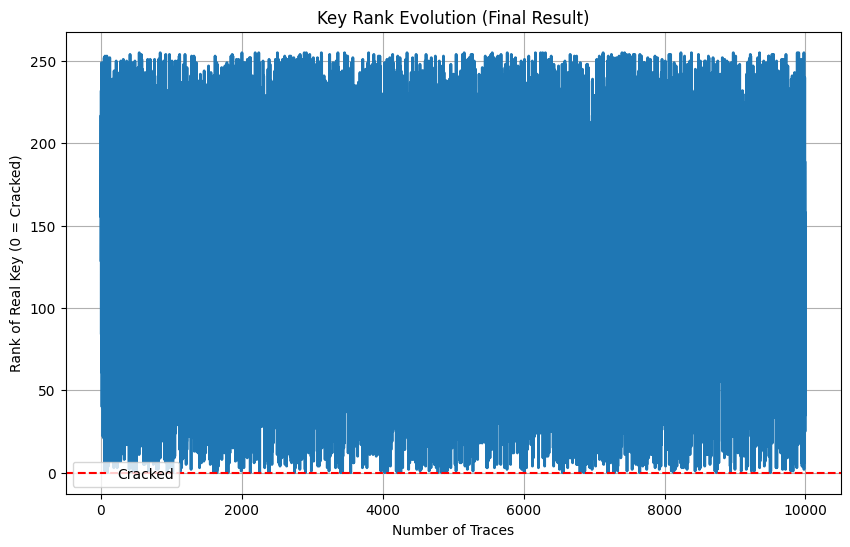

Final Rank after 10000 traces: 133
INCOMPLETE: The model needs more traces or better training.


In [9]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
MODEL_FILE = 'best_ascad_model.keras'
DATA_FILE = 'ascadv2-extracted.h5'
NUM_ATTACK_TRACES = 10000  # How many traces to use for the attack
REAL_KEY_BYTE_INDEX = 0   # Wattack the first byte of the key

# AES SBox (Lookup Table)
AES_Sbox = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

print("1. Loading Model...")
# Load the best model saved earlier
model = tf.keras.models.load_model(MODEL_FILE)

print(f"2. Loading {NUM_ATTACK_TRACES} Attack Traces...")
with h5py.File(DATA_FILE, "r") as f:
    # Load traces
    traces = f['Attack_traces/traces'][:NUM_ATTACK_TRACES]
    # Load metadata (Plaintexts and Keys)
    plaintexts = f['Attack_traces/metadata']['plaintext'][:NUM_ATTACK_TRACES]
    keys = f['Attack_traces/metadata']['key'][:NUM_ATTACK_TRACES]

# Reshape traces for the CNN (Batch, Time, 1)
traces = traces.reshape((traces.shape[0], traces.shape[1], 1))

print("3. Getting Model Predictions (This uses the GPU)...")
# Get probability predictions for all traces at once
predictions = model.predict(traces, batch_size=256, verbose=1)

print("4. Calculating Rank Evolution...")

# accumulate the log-probability of each key guess
# Start with 0 probability for all 256 possible keys
key_probabilities = np.zeros(256)

rank_evolution = []

# Loop through every trace and update the guess
for i in tqdm(range(NUM_ATTACK_TRACES)):
    real_key = keys[i][REAL_KEY_BYTE_INDEX]
    plaintext_byte = plaintexts[i][REAL_KEY_BYTE_INDEX]
    
    # For this single trace, check all 256 possible key guesses
    for k_guess in range(256):
        # If the key was 'k_guess', what would the SBox output be?
        sbox_out = AES_Sbox[plaintext_byte ^ k_guess]
        
        # Ask the model: "How likely is this SBox output?"
        # take the log to avoid tiny numbers (underflow)
        # add a tiny epsilon (1e-40) to avoid log(0) errors
        prob = predictions[i][sbox_out]
        key_probabilities[k_guess] += np.log(prob + 1e-5)
    
    # After updating probs with this trace, where does the REAL key rank?
    # sort guesses by probability (Descending)
    sorted_indices = np.argsort(key_probabilities)[::-1]
    
    # Find the rank of the real key (0 is best, 255 is worst)
    rank = np.where(sorted_indices == real_key)[0][0]
    rank_evolution.append(rank)

print("5. Plotting Results...")
plt.figure(figsize=(10, 6))
plt.plot(rank_evolution, linewidth=2)
plt.title(f'Key Rank Evolution (Final Result)')
plt.xlabel('Number of Traces')
plt.ylabel('Rank of Real Key (0 = Cracked)')
plt.grid(True)
# Draw a red line at 0 to show the goal
plt.axhline(y=0, color='r', linestyle='--', label='Cracked')
plt.legend()
plt.show()

print(f"Final Rank after {NUM_ATTACK_TRACES} traces: {rank_evolution[-1]}")
if rank_evolution[-1] == 0:
    print("SUCCESS: The model successfully recovered the key!")
else:
    print("INCOMPLETE: The model needs more traces or better training.")

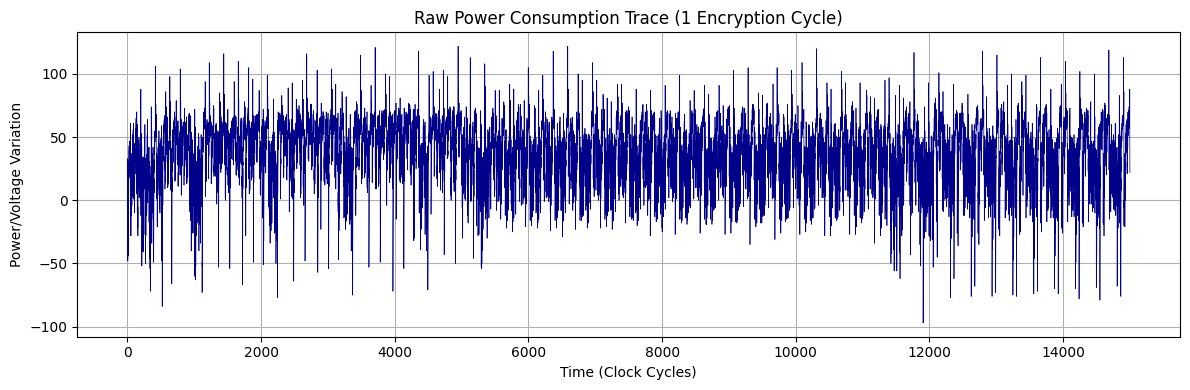

In [3]:
#Code for slide2 visual
import h5py
import matplotlib.pyplot as plt


DATA_FILE = 'ascadv2-extracted.h5' 

#Open the dataset and grab a single trace
with h5py.File(DATA_FILE, "r") as f:
    raw_trace = f['Attack_traces/traces'][0]

#presentation-ready plot
plt.figure(figsize=(12, 4))
plt.plot(raw_trace, linewidth=0.5, color='darkblue')

plt.title('Raw Power Consumption Trace (1 Encryption Cycle)')
plt.xlabel('Time (Clock Cycles)')
plt.ylabel('Power/Voltage Variation')
plt.grid(True)
plt.tight_layout()

plt.show()

In [11]:
#code block from secondary notebook, trained new model to achive better results rank of 32
#10k Training Set
#i had to train a new model called newbest_ascad_model.keras , both are about 113MB, this is for 50 epochs
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Updated EPOCHS is defined
EPOCHS = 50

#UPGRADE 1: ENABLE MIXED PRECISION
mixed_precision.set_global_policy('mixed_float16')

print(f"Compute Dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable Dtype: {mixed_precision.global_policy().variable_dtype}")

input_shape = (X_train.shape[1], 1)

# UPGRADE 2: THE 'SELU' ARCHITECTURE 
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    
    # THE RAM SAVER: On-the-fly Normalization
    # This standardizes the data inside the GPU VRAM batch-by-batch!
    tf.keras.layers.BatchNormalization(),
    
    # Block 1: Wide Vision
    tf.keras.layers.Conv1D(64, 50, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    
    # Block 2: Medium Vision
    tf.keras.layers.Conv1D(128, 25, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    
    # Block 3: Focused Vision
    tf.keras.layers.Conv1D(256, 11, activation='selu', padding='same', kernel_initializer='lecun_normal'),
    tf.keras.layers.AveragePooling1D(2),
    
    # Global Pooling
    tf.keras.layers.GlobalAveragePooling1D(),
    
    # Classifier 
    tf.keras.layers.Dense(2048, activation='selu', kernel_initializer='lecun_normal'),
    tf.keras.layers.AlphaDropout(0.3), 
    
    tf.keras.layers.Dense(2048, activation='selu', kernel_initializer='lecun_normal'),
    tf.keras.layers.AlphaDropout(0.3),
    
    # Output Layer 
    tf.keras.layers.Dense(256, activation='softmax', dtype='float32') 
])

# Compile
model.compile(loss='categorical_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
              metrics=['accuracy'])

# --- NEW CALLBACKS ---
callbacks = [
    ModelCheckpoint(
        'newbest_ascad_model.keras', 
        monitor='val_loss',          
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

print("Starting Memory-Safe Training...")
history = model.fit(
    x=X_train,
    y=Y_train,
    epochs=EPOCHS,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    batch_size=256, 
    verbose=1
)

In [12]:
#optmized model for 10k
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
MODEL_FILE = 'newbest_ascad_model.keras'
DATA_FILE = 'ascadv2-extracted.h5'
NUM_ATTACK_TRACES = 10000  # How many traces to use for the attack
REAL_KEY_BYTE_INDEX = 0   # attacking the first byte of the key

# AES SBox (Lookup Table)
AES_Sbox = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
])

print("1. Loading Model...")
# Load the best model saved earlier
model = tf.keras.models.load_model(MODEL_FILE)

print(f"2. Loading {NUM_ATTACK_TRACES} Attack Traces...")
with h5py.File(DATA_FILE, "r") as f:
    # Load traces
    traces = f['Attack_traces/traces'][:NUM_ATTACK_TRACES]
    # Load metadata (Plaintexts and Keys)
    plaintexts = f['Attack_traces/metadata']['plaintext'][:NUM_ATTACK_TRACES]
    keys = f['Attack_traces/metadata']['key'][:NUM_ATTACK_TRACES]

# Reshape traces for the CNN (Batch, Time, 1)
traces = traces.reshape((traces.shape[0], traces.shape[1], 1))

print("3. Getting Model Predictions (This uses the GPU)...")
# Get probability predictions for all traces at once
predictions = model.predict(traces, batch_size=256, verbose=1)

print("4. Calculating Rank Evolution...")

# I will accumulate the log-probability of each key guess
# Start with 0 probability for all 256 possible keys
key_probabilities = np.zeros(256)

rank_evolution = []


# Loop through every trace and update the guess
for i in tqdm(range(NUM_ATTACK_TRACES)):
    real_key = keys[i][REAL_KEY_BYTE_INDEX]
    plaintext_byte = plaintexts[i][REAL_KEY_BYTE_INDEX]
    
    # For this single trace, check all 256 possible key guesses
    for k_guess in range(256):
        # If the key was 'k_guess', what would the SBox output be?
        sbox_out = AES_Sbox[plaintext_byte ^ k_guess]
        
        # Ask the model: "How likely is this SBox output?"
        prob = predictions[i][sbox_out]
        
        # THE FIX: Stop using np.log(). Just add the raw probabilities together
        # This prevents a single bad guess from permanently destroying the real key's score.
        key_probabilities[k_guess] += prob
    
    # After updating probs with this trace, where does the REAL key rank?
    # I sort the guesses by probability (Descending)
    sorted_indices = np.argsort(key_probabilities)[::-1]
    
    # Find the rank of the real key (0 is best, 255 is worst)
    rank = np.where(sorted_indices == real_key)[0][0]
    rank_evolution.append(rank)

print("5. Plotting Results...")
plt.figure(figsize=(10, 6))
plt.plot(rank_evolution, linewidth=2)
plt.title(f'Key Rank Evolution (Final Result)')
plt.xlabel('Number of Traces')
plt.ylabel('Rank of Real Key (0 = Cracked)')
plt.grid(True)
# Draw a red line at 0 to show the goal
plt.axhline(y=0, color='r', linestyle='--', label='Cracked')
plt.legend()
plt.show()

print(f"Final Rank after {NUM_ATTACK_TRACES} traces: {rank_evolution[-1]}")
if rank_evolution[-1] == 0:
    print("SUCCESS: The model successfully recovered the key!")
else:
    print("INCOMPLETE: The model needs more traces or better training.")


In [ ]:
#output of result is in presentation ppt